In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os
os.environ["KAGGLEHUB_CACHE"] = "/Volumes/SecureSSD/Projects/LearningML/kaggle"

In [2]:
path = kagglehub.dataset_download("ishanshrivastava28/superstore-sales")

In [3]:
df = pd.read_csv(path+'/'+'Superstore.csv', encoding='latin1')

In [4]:
profit_df = df.groupby('State')['Profit'].sum().reset_index().sort_values(by = 'Profit', ascending = False).reset_index().head(5)
unique_count = df.groupby('State')['Customer ID'].nunique().reset_index()
profit_df.merge(unique_count, on = 'State')

,index,State,Profit,Customer ID
0,3,California,76381.3871,577
1,30,New York,74038.5486,415
2,45,Washington,33402.6517,224
3,20,Michigan,24463.1876,106
4,44,Virginia,18597.9504,107


In [5]:
highest_order_customer = df.groupby('Customer ID')['Order ID'].nunique().reset_index().sort_values(by = 'Order ID', ascending = False).reset_index(drop = True)['Customer ID'].head(1).to_string(index = False)
df[df['Customer ID'] == highest_order_customer].groupby('Category')['Sales'].sum().reset_index()

,Category,Sales
0,Furniture,2860.0848
1,Office Supplies,1258.1180
2,Technology,1359.8580


In [6]:
pd.pivot_table(df, values = 'Discount', index = ['Ship Mode'], aggfunc='mean').reset_index().merge(df.groupby('Ship Mode')['Profit'].sum().reset_index()).sort_values(by = 'Profit', ascending=False).reset_index(drop = True)

,Ship Mode,Discount,Profit
0,Standard Class,0.160023,164088.7875
1,Second Class,0.138895,57446.6354
2,First Class,0.164610,48969.8399
3,Same Day,0.152394,15891.7589


In [7]:
df['Discount'].corr(df['Profit'])

np.float64(-0.2194874563717679)

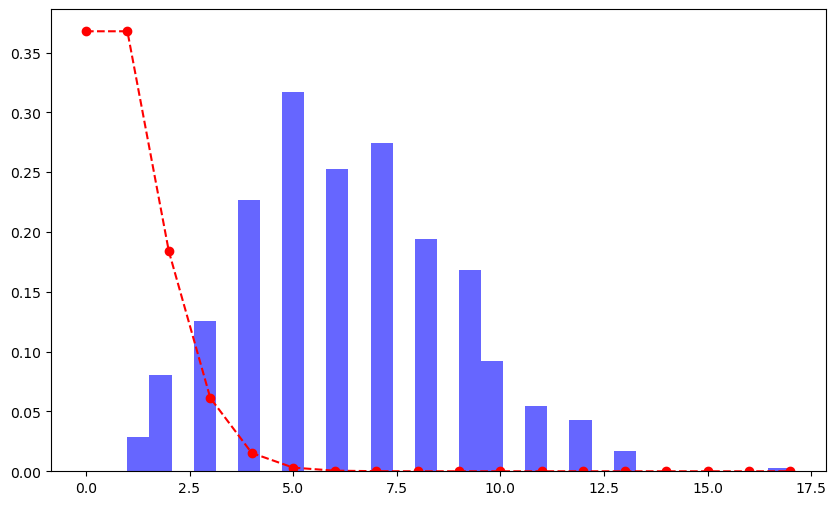

In [17]:
from scipy.stats import poisson
of_df = df.groupby('Customer ID')['Order ID'].nunique()
ok = of_df.mean()
x = np.arange(0, of_df.max() + 1)
pdf = poisson.pmf(x, 1)
plt.figure(figsize=(10, 6))
plt.hist(of_df, bins = 30, density=True, alpha = 0.6, color='b', label = 'orders')
plt.plot(x, pdf, 'r--', marker = 'o', label = 'lambda')

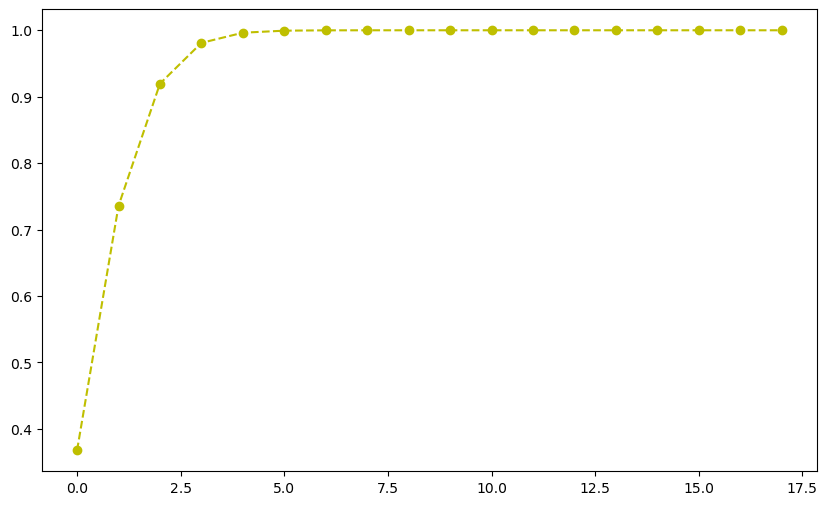

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(x, poisson.cdf(x, 1), 'y--', marker = 'o', label = 'lambda')
